In [1]:
import importlib
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output, display

import storage_model
importlib.reload(storage_model)
from storage_model import Storage
from pathlib import Path


FORWARD CURVES FROM TTF Q.XLSX:


In [2]:
# Read TTF forward curve matrix
QUOTE_FILE = "ttf q.xlsx"
quote_path = Path.cwd() / QUOTE_FILE
if not quote_path.exists():
    matches = sorted(Path.cwd().glob("*ttf*q*.xlsx"))
    if matches:
        quote_path = matches[0]
    else:
        raise FileNotFoundError(f"Could not find {QUOTE_FILE!r} in {Path.cwd()}")

quotes = pd.read_excel(str(quote_path))
quotes = quotes.rename(columns={quotes.columns[0]: "quote_date"})
quotes = quotes.dropna(subset=["quote_date"]).copy()
quotes["quote_date"] = pd.to_datetime(quotes["quote_date"], format="mixed")
quotes = quotes.sort_values("quote_date").reset_index(drop=True)

contract_columns = sorted(
    [c for c in quotes.columns if re.fullmatch(r"TTFc\d+", str(c))],
    key=lambda c: int(re.search(r"\d+", str(c)).group()),
)

print(
    f"Loaded {len(quotes):,} quote dates and {len(contract_columns)} monthly forward contracts "
    f"from {quote_path}: {quotes['quote_date'].min():%Y-%m-%d} to {quotes['quote_date'].max():%Y-%m-%d}."
)
display(quotes.tail())


Loaded 4,171 quote dates and 55 monthly forward contracts from c:\ClaudeCode\Github\dmitry-goryunov\Storage\ttf q.xlsx: 2010-03-12 to 2026-03-06.


,quote_date,DA,TTFc1,TTFc2,TTFc3,TTFc4,TTFc5,TTFc6,TTFc7,TTFc8,...,TTFc46,TTFc47,TTFc48,TTFc49,TTFc50,TTFc51,TTFc52,TTFc53,TTFc54,TTFc55
4166,2026-03-02,43.53,44.506,43.238,41.964,40.824,39.620,39.146,37.930,37.679,...,21.929,22.124,22.009,20.373,19.973,19.533,19.548,19.918,20.453,21.399
4167,2026-03-03,53.60,54.290,52.889,51.019,49.603,48.321,47.477,46.862,45.961,...,22.037,22.227,22.107,20.425,20.025,19.580,19.596,19.971,20.506,21.600
4168,2026-03-04,48.55,48.767,46.872,45.128,43.405,41.968,41.168,40.682,40.111,...,21.925,22.110,21.995,20.415,20.015,19.570,19.585,19.960,20.550,21.749
4169,2026-03-05,50.04,50.731,48.882,47.350,45.548,44.106,43.444,43.155,42.595,...,22.054,22.239,22.129,20.454,20.054,19.604,19.280,19.655,20.600,21.440
4170,2026-03-06,52.00,53.385,52.286,51.141,49.803,48.831,48.482,48.336,48.014,...,22.704,22.854,22.744,21.164,20.764,20.314,19.664,20.044,20.719,21.679


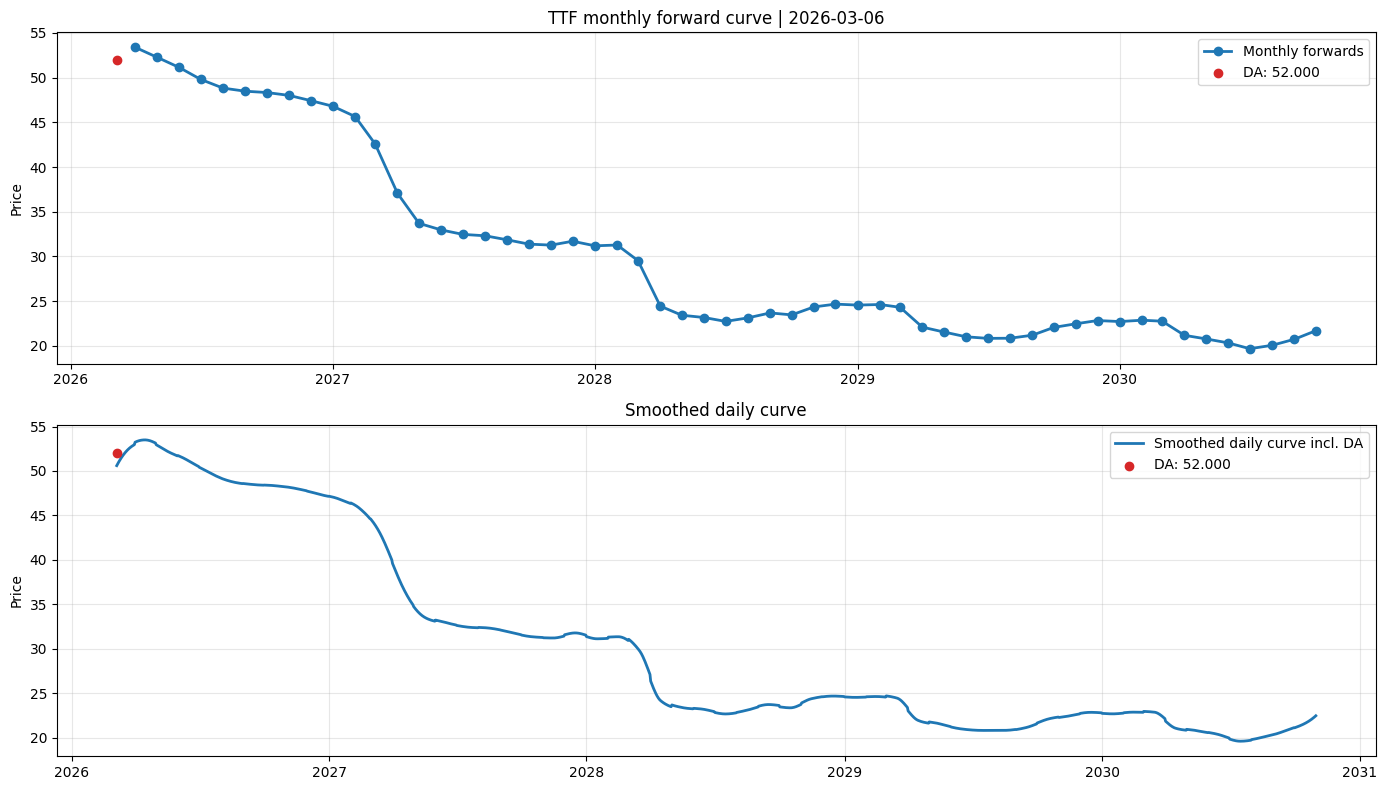

In [3]:
# Build monthly and daily curves from the selected quote date
# The new file structure is quote_date + DA + TTFc1..TTFc55.
# TTFc1 is treated as the front-month contract, i.e. the next calendar month after quote_date.
# TTFc2, TTFc3, ... are consecutive monthly contracts.
# DA is included as the first daily anchor at quote_date before smoothing.
# Daily curves are smoothed with storage_model.smoothen_curve, the same PCHIP algorithm used by Storage.

def _month_start(ts):
    ts = pd.Timestamp(ts)
    return pd.Timestamp(ts.year, ts.month, 1)


def _month_end(ts):
    return _month_start(ts) + pd.offsets.MonthEnd(0)


def _front_month_start(quote_date):
    return _month_start(quote_date) + pd.DateOffset(months=1)


def selected_quote_row(quote_date):
    quote_date = pd.Timestamp(quote_date)
    return quotes.loc[quotes["quote_date"].eq(quote_date)].iloc[0]


def monthly_curve_from_quote(row):
    front_month = _front_month_start(row["quote_date"])
    data = []

    for col in contract_columns:
        value = row[col]
        if pd.isna(value):
            continue
        contract_number = int(re.search(r"\d+", col).group())
        contract_start = front_month + pd.DateOffset(months=contract_number - 1)
        data.append((contract_start, float(value), col))

    if not data:
        return pd.Series(dtype=float, name="value"), pd.DataFrame(columns=["contract", "contractStart", "contractEnd", "value"])

    curve_df = pd.DataFrame(data, columns=["contractStart", "value", "contract"])
    curve_df["contractEnd"] = curve_df["contractStart"].map(_month_end)
    curve_df = curve_df[["contract", "contractStart", "contractEnd", "value"]]

    monthly = curve_df.set_index("contractStart")["value"].sort_index().rename("value")
    return monthly, curve_df


def stepped_daily_curve_from_monthly(monthly):
    if monthly.empty:
        return pd.Series(dtype=float, name="value")
    day_index = pd.date_range(monthly.index.min(), _month_end(monthly.index.max()), freq="D")
    daily = pd.Series(index=day_index, dtype=float, name="value")
    for month_start, value in monthly.items():
        mask = (daily.index >= month_start) & (daily.index <= _month_end(month_start))
        daily.loc[mask] = value
    return daily


def daily_curve_from_monthly(monthly, quote_date=None, da_value=np.nan):
    stepped_daily = stepped_daily_curve_from_monthly(monthly)

    if pd.notna(da_value) and quote_date is not None and not stepped_daily.empty:
        quote_date = pd.Timestamp(quote_date)
        daily_index = pd.date_range(quote_date, stepped_daily.index.max(), freq="D")
        anchored = pd.Series(index=daily_index, dtype=float, name="value")
        anchored.loc[quote_date] = float(da_value)
        anchored.loc[stepped_daily.index] = stepped_daily.values
        stepped_daily = anchored.ffill()

    if stepped_daily.empty:
        return stepped_daily
    return storage_model.smoothen_curve(stepped_daily).rename("value")


def plot_forward_curve(quote_date, curve_view):
    plt.close("all")
    row = selected_quote_row(quote_date)
    monthly, curve_df = monthly_curve_from_quote(row)
    spot = row.get("DA", np.nan)
    daily = daily_curve_from_monthly(monthly, row["quote_date"], spot)

    if monthly.empty:
        print("No usable TTFc monthly quotes for this date.")
        return

    spot_label = f"DA: {spot:.3f}" if pd.notna(spot) else "DA: n/a"

    if curve_view == "Monthly":
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(monthly.index, monthly.values, marker="o", linewidth=2, label="Monthly forwards")
        if pd.notna(spot):
            ax.scatter([pd.Timestamp(quote_date)], [spot], color="tab:red", zorder=3, label=spot_label)
        ax.set_title(f"TTF monthly forward curve | {pd.Timestamp(quote_date):%Y-%m-%d}")
        ax.set_ylabel("Price")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()
        display(curve_df.head(24))
        return

    if curve_view == "Daily":
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(daily.index, daily.values, linewidth=2, label="Smoothed daily curve incl. DA")
        if pd.notna(spot):
            ax.scatter([pd.Timestamp(quote_date)], [spot], color="tab:red", zorder=3, label=spot_label)
        ax.set_title(f"TTF smoothed daily forward curve | {pd.Timestamp(quote_date):%Y-%m-%d}")
        ax.set_ylabel("Price")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    axes[0].plot(monthly.index, monthly.values, marker="o", linewidth=2, label="Monthly forwards")
    if pd.notna(spot):
        axes[0].scatter([pd.Timestamp(quote_date)], [spot], color="tab:red", zorder=3, label=spot_label)
    axes[0].set_title(f"TTF monthly forward curve | {pd.Timestamp(quote_date):%Y-%m-%d}")
    axes[0].set_ylabel("Price")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(daily.index, daily.values, linewidth=2, label="Smoothed daily curve incl. DA")
    if pd.notna(spot):
        axes[1].scatter([pd.Timestamp(quote_date)], [spot], color="tab:red", zorder=3, label=spot_label)
    axes[1].set_title("Smoothed daily curve")
    axes[1].set_ylabel("Price")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Set these and rerun this cell to draw exactly one forward-curve view.
forward_curve_date = quotes["quote_date"].iloc[-1]
curve_view = "Both"  # "Both", "Monthly", or "Daily"

clear_output(wait=True)
plt.close("all")
plot_forward_curve(forward_curve_date, curve_view)


Product type:                 call_swing
Forward curve date requested: 2026-01-10
Forward curve quote used:     2026-01-09
Curve covers:                 2026-01-01 to 2030-08-31
Flat metric       = 26.7782
Profiled metric   = 27.3260
Intrinsic value   = 0.5478
Extrinsic value   = 2.2897
Total value       = 2.8374


,metric,value
0,product_type,call_swing
1,FDDate_requested,2026-01-10 00:00:00
2,forward_quote_used,2026-01-09 00:00:00
3,flat_metric,26.778224
4,profiled_metric,27.325992
5,arithmetic_flat_metric,26.778224
6,flat_minus_arithmetic,0.0
7,intrinsic_value,0.547768
8,extrinsic_value,2.289652
9,total_value,2.83742


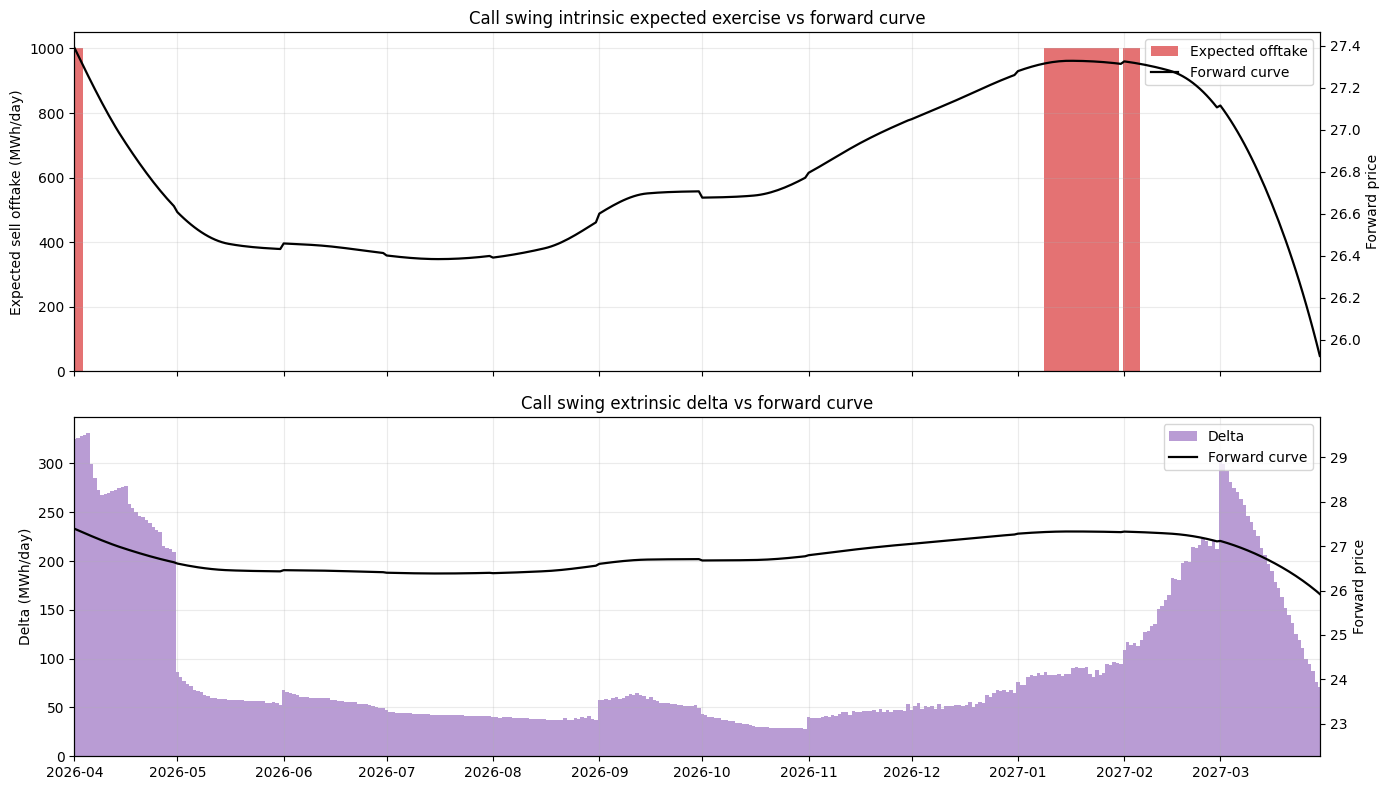

Run finished. If VS Code says outputs are collapsed, expand the cell output to see the table and charts.


In [ ]:
# Value put swing, call swing, or storage from a changeable historical forward curve date.
# Set product_type to one of: "put_swing", "call_swing", "storage".

product_type = "put_swing"

FDDate       = pd.Timestamp("2026-01-10")
valDate      = pd.Timestamp("2026-01-01")
storageStart = pd.Timestamp("2026-04-01")
storageEnd   = pd.Timestamp("2027-03-30")
days         = 30       # used by put_swing and call_swing
vol          = 0.60
n_p_full     = 30
run_intrinsic = True   # Set False to skip the profiled intrinsic build/decomposition.
v_step       = 1000

# Used only when product_type == "storage"
inj_days     = 30
wdr_days     = 30
inj_cost     = 0.5
wdr_cost     = 0.5

def quote_row_for_fd_date(fd_date, exact=False):
    fd_date = pd.Timestamp(fd_date)
    if exact:
        eligible = quotes.loc[quotes["quote_date"].eq(fd_date)]
    else:
        eligible = quotes.loc[quotes["quote_date"] <= fd_date]
    eligible = eligible.loc[eligible[contract_columns].notna().any(axis=1)]
    if eligible.empty:
        raise ValueError(f"No forward quote available for FDDate {fd_date:%Y-%m-%d}")
    return eligible.iloc[-1]


def curve_df_for_storage(row, curve_start=None, include_da=True):
    monthly, curve_df = monthly_curve_from_quote(row)
    curve_df = curve_df.copy()

    if not monthly.empty:
        full_months = pd.date_range(monthly.index.min(), monthly.index.max(), freq="MS")
        monthly = monthly.reindex(full_months).interpolate(method="time").ffill().bfill()
        curve_df = pd.DataFrame({
            "contract": [f"TTFc{i + 1}" for i in range(len(monthly))],
            "contractStart": monthly.index,
            "value": monthly.values,
        })
        curve_df["contractEnd"] = curve_df["contractStart"].map(_month_end)
        curve_df = curve_df[["contract", "contractStart", "contractEnd", "value"]]

    quote_date = pd.Timestamp(row["quote_date"])
    curve_start = pd.Timestamp(curve_start) if curve_start is not None else quote_date

    # Use DA as the front stub so Storage has a finite curve before TTFc1.
    if include_da and pd.notna(row.get("DA", np.nan)):
        front_month = _front_month_start(quote_date)
        da_start = min(curve_start, quote_date)
        da_end = front_month - pd.Timedelta(days=1)
        da_row = pd.DataFrame([{
            "contract": "DA",
            "contractStart": da_start,
            "contractEnd": da_end,
            "value": float(row["DA"]),
        }])
        curve_df = pd.concat([da_row, curve_df], ignore_index=True)
    elif curve_start < curve_df["contractStart"].min():
        first_value = float(curve_df.sort_values("contractStart").iloc[0]["value"])
        first_start = curve_df["contractStart"].min()
        stub_row = pd.DataFrame([{
            "contract": "FRONT_STUB",
            "contractStart": curve_start,
            "contractEnd": first_start - pd.Timedelta(days=1),
            "value": first_value,
        }])
        curve_df = pd.concat([stub_row, curve_df], ignore_index=True)

    result = curve_df[["contractStart", "contractEnd", "value"]].sort_values("contractStart").reset_index(drop=True)
    if result["value"].isna().any():
        raise ValueError("Storage curve contains missing values after interpolation/stub fill.")
    return result


def _active_masks(model):
    n = len(model.date_span)
    active = np.ones(n)
    active[model._active:] = 0.0
    active[:model.Dt] = 0.0
    return n, active


def _daily_arithmetic_flat_metric(model):
    exercise_dates = model.date_span[model.Dt:model._active]
    return float(pd.Series(model.price_curve, index=model.date_span).loc[exercise_dates].mean())


def value_put_swing(curve):
    # BUY/inject right: value is saving from choosing low-price days/scenarios.
    s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=v_step, sVol=vol)
    n, active = _active_masks(s)
    s.i_curve = active.copy()
    s.w_curve = np.zeros(n)

    flat_metric = _daily_arithmetic_flat_metric(s)

    s.set_volume_states(days)
    s.n_op_start = 0
    s.t_p_curve = np.full(s.n_op + 2, -1e9)
    s.t_p_curve[days] = 0.0
    if run_intrinsic:
        s.build()
        profiled_eur = s.v[0, 0, 0]
        acq = -np.sum(s.delta)
        profiled_metric = s.profiled()
        intrinsic = flat_metric - profiled_metric
        intrinsic_profile_raw = -np.array(s.exp_ex)  # positive buy volume
    else:
        profiled_eur = np.nan
        acq = np.nan
        profiled_metric = np.nan
        intrinsic = np.nan
        intrinsic_profile_raw = np.zeros(len(s.date_span))

    s.n_p = n_p_full
    s.build()
    full_eur = s.v[0, s.n_p, 0]
    full_acq = np.sum(s.delta)
    stochastic_metric = full_eur / full_acq
    extrinsic = (full_eur - profiled_eur) / acq if run_intrinsic else np.nan
    extrinsic_profile_raw = -np.array(s.exp_ex)

    return s, {
        "flat_metric": flat_metric,
        "profiled_metric": profiled_metric,
        "intrinsic": intrinsic,
        "extrinsic": extrinsic,
        "total": intrinsic + extrinsic if run_intrinsic else stochastic_metric,
        "stochastic_metric": stochastic_metric,
        "profile_label": "Expected buy offtake (MWh/day)",
        "title_prefix": "Put swing",
        "intrinsic_profile_raw": intrinsic_profile_raw,
        "extrinsic_profile_raw": extrinsic_profile_raw,
    }


def value_call_swing(curve):
    # SELL/withdraw right: value is uplift from choosing high-price days/scenarios.
    s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=v_step, sVol=vol)
    flat_metric = _daily_arithmetic_flat_metric(s)

    s.set_volume_states(days)  # start with exactly `days` sell clips available; terminal state 0 is enforced.
    if run_intrinsic:
        s.build()
        profiled_eur = s.v[0, 0, s.n_op_start]
        acq = np.sum(s.delta)
        profiled_metric = s.profiled()
        intrinsic = profiled_metric - flat_metric
        intrinsic_profile_raw = np.array(s.exp_ex)  # positive sell volume
    else:
        profiled_eur = np.nan
        acq = np.nan
        profiled_metric = np.nan
        intrinsic = np.nan
        intrinsic_profile_raw = np.zeros(len(s.date_span))

    s.n_p = n_p_full
    s.build()
    full_eur = s.v[0, s.n_p, s.n_op_start]
    full_acq = np.sum(s.delta)
    stochastic_metric = full_eur / full_acq
    extrinsic = (full_eur - profiled_eur) / acq if run_intrinsic else np.nan
    extrinsic_profile_raw = np.array(s.exp_ex)

    return s, {
        "flat_metric": flat_metric,
        "profiled_metric": profiled_metric,
        "intrinsic": intrinsic,
        "extrinsic": extrinsic,
        "total": intrinsic + extrinsic if run_intrinsic else stochastic_metric,
        "stochastic_metric": stochastic_metric,
        "profile_label": "Expected sell offtake (MWh/day)",
        "title_prefix": "Call swing",
        "intrinsic_profile_raw": intrinsic_profile_raw,
        "extrinsic_profile_raw": extrinsic_profile_raw,
    }


def value_storage(curve):
    # Storage: buy low, sell high, start and end empty.
    if inj_days != wdr_days:
        print("Note: storage uses a one-clip daily injection/withdrawal grid; wdr_days is informational unless it equals inj_days.", flush=True)
    s = Storage(valDate, storageStart, storageEnd, curve=curve, n_p=0, v_step=v_step, sVol=vol)
    n, active = _active_masks(s)
    s.i_curve = active.copy()
    s.w_curve = active.copy()
    s.i_cost[:] = inj_cost
    s.w_cost[:] = wdr_cost
    s.set_volume_states(inj_days)
    s.n_op_start = 0
    s.t_p_curve = np.full(s.n_op + 2, -1e9)
    s.t_p_curve[0] = 0.0

    max_vol = inj_days * s.v_step
    if run_intrinsic:
        print("Building storage intrinsic case (first run may spend ~20-40s compiling Numba kernels)...", flush=True)
        t0 = time.perf_counter()
        s.build()
        print(f"Storage intrinsic build complete in {time.perf_counter() - t0:.1f}s", flush=True)
        intrinsic_eur = s.v[0, 0, 0]
        intrinsic_profile_raw = np.array(s.exp_ex)  # positive sell, negative buy
    else:
        intrinsic_eur = np.nan
        intrinsic_profile_raw = np.zeros(len(s.date_span))

    s.n_p = n_p_full
    print(f"Building storage full tree with n_p={n_p_full}...", flush=True)
    t0 = time.perf_counter()
    s.build()
    print(f"Storage full-tree build complete in {time.perf_counter() - t0:.1f}s", flush=True)
    total_eur = s.v[0, s.n_p, 0]
    extrinsic_eur = total_eur - intrinsic_eur if run_intrinsic else np.nan
    extrinsic_profile_raw = np.array(s.exp_ex)

    return s, {
        "flat_metric": np.nan,
        "profiled_metric": intrinsic_eur / max_vol if run_intrinsic else np.nan,
        "intrinsic": intrinsic_eur / max_vol if run_intrinsic else np.nan,
        "extrinsic": extrinsic_eur / max_vol if run_intrinsic else np.nan,
        "total": total_eur / max_vol,
        "stochastic_metric": total_eur / max_vol,
        "intrinsic_eur": intrinsic_eur,
        "extrinsic_eur": extrinsic_eur,
        "total_eur": total_eur,
        "profile_label": "Expected exercise: sell + / buy - (MWh/day)",
        "title_prefix": "Storage",
        "intrinsic_profile_raw": intrinsic_profile_raw,
        "extrinsic_profile_raw": extrinsic_profile_raw,
    }


def full_value_eur(curve_input):
    if product_type == "put_swing":
        sb = Storage(valDate, storageStart, storageEnd, curve=curve_input, n_p=n_p_full, v_step=v_step, sVol=vol)
        n, active = _active_masks(sb)
        sb.i_curve = active.copy()
        sb.w_curve = np.zeros(n)
        sb.set_volume_states(days)
        sb.n_op_start = 0
        sb.t_p_curve = np.full(sb.n_op + 2, -1e9)
        sb.t_p_curve[days] = 0.0
        sb.build()
        return sb.v[0, sb.n_p, 0]

    if product_type == "call_swing":
        sb = Storage(valDate, storageStart, storageEnd, curve=curve_input, n_p=n_p_full, v_step=v_step, sVol=vol)
        sb.set_volume_states(days)
        sb.build()
        return sb.v[0, sb.n_p, sb.n_op_start]

    if product_type == "storage":
        sb = Storage(valDate, storageStart, storageEnd, curve=curve_input, n_p=n_p_full, v_step=v_step, sVol=vol)
        n, active = _active_masks(sb)
        sb.i_curve = active.copy()
        sb.w_curve = active.copy()
        sb.i_cost[:] = inj_cost
        sb.w_cost[:] = wdr_cost
        sb.set_volume_states(inj_days)
        sb.n_op_start = 0
        sb.t_p_curve = np.full(sb.n_op + 2, -1e9)
        sb.t_p_curve[0] = 0.0
        sb.build()
        return sb.v[0, sb.n_p, 0]

    raise ValueError('product_type must be "put_swing", "call_swing", or "storage"')


fd_quote = quote_row_for_fd_date(FDDate, exact=False)
curve = curve_df_for_storage(fd_quote, curve_start=valDate, include_da=True)

print(f"Product type:                 {product_type}")
print(f"Forward curve date requested: {FDDate:%Y-%m-%d}")
print(f"Forward curve quote used:     {fd_quote['quote_date']:%Y-%m-%d}")
print(f"Curve covers:                 {curve['contractStart'].min():%Y-%m-%d} to {curve['contractEnd'].max():%Y-%m-%d}")

if product_type == "put_swing":
    s, result = value_put_swing(curve)
elif product_type == "call_swing":
    s, result = value_call_swing(curve)
elif product_type == "storage":
    s, result = value_storage(curve)
else:
    raise ValueError('product_type must be "put_swing", "call_swing", or "storage"')

print(f"Flat metric       = {result['flat_metric']:.4f}" if pd.notna(result["flat_metric"]) else "Flat metric       = n/a")
print(f"Profiled metric   = {result['profiled_metric']:.4f}")
print(f"Intrinsic value   = {result['intrinsic']:.4f}")
print(f"Extrinsic value   = {result['extrinsic']:.4f}")
print(f"Total value       = {result['total']:.4f}" if run_intrinsic else f"Stochastic metric = {result['stochastic_metric']:.4f}")
if product_type == "storage":
    print(f"Intrinsic EUR     = {result['intrinsic_eur']:,.0f}")
    print(f"Extrinsic EUR     = {result['extrinsic_eur']:,.0f}")
    print(f"Total EUR         = {result['total_eur']:,.0f}")

exercise_dates = s.date_span[s.Dt:s._active]
plot_prices = pd.Series(s.price_curve, index=s.date_span)
arithmetic_flat_metric = (
    float(plot_prices.loc[exercise_dates].mean())
    if product_type in ("put_swing", "call_swing")
    else np.nan
)
flat_metric_difference = result["flat_metric"] - arithmetic_flat_metric if pd.notna(result["flat_metric"]) else np.nan

swing_summary = pd.DataFrame({
    "metric": [
        "product_type",
        "FDDate_requested",
        "forward_quote_used",
        "flat_metric",
        "profiled_metric",
        "arithmetic_flat_metric",
        "flat_minus_arithmetic",
        "intrinsic_value",
        "extrinsic_value",
        "total_value",
    ],
    "value": [
        product_type,
        FDDate,
        fd_quote["quote_date"],
        result["flat_metric"],
        result["profiled_metric"],
        arithmetic_flat_metric,
        flat_metric_difference,
        result["intrinsic"],
        result["extrinsic"],
        result["total"],
    ],
})
display(swing_summary)

# Expected exercise/offtake profiles vs forward curve
exercise_dates = s.date_span[s.Dt:s._active]
delta_dates = s.date_span[:s.n_t]
plot_prices = pd.Series(s.price_curve, index=s.date_span)
intrinsic_profile = pd.Series(result["intrinsic_profile_raw"][:len(s.date_span)], index=s.date_span).loc[exercise_dates]
extrinsic_profile = pd.Series(result["extrinsic_profile_raw"][:len(s.date_span)], index=s.date_span).loc[exercise_dates]
extrinsic_delta_profile = pd.Series(np.array(s.delta[:s.n_t], dtype=float), index=delta_dates)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, profile, title, color in [
    (axes[0], intrinsic_profile, f"{result['title_prefix']} intrinsic expected exercise vs forward curve", "tab:red"),
    (axes[1], extrinsic_delta_profile, f"{result['title_prefix']} extrinsic delta vs forward curve", "tab:purple"),
]:
    dates = exercise_dates if ax is axes[0] else delta_dates
    ax_price = ax.twinx()
    if product_type == "storage":
        ax.bar(dates, np.where(profile.values > 0, profile.values, 0), width=1.0, color="tab:green", alpha=0.65, label="Expected sell" if ax is axes[0] else "Positive delta")
        ax.bar(dates, np.where(profile.values < 0, profile.values, 0), width=1.0, color="tab:red", alpha=0.65, label="Expected buy" if ax is axes[0] else "Negative delta")
    else:
        ax.bar(dates, profile.values, width=1.0, color=color, alpha=0.65, label="Expected offtake" if ax is axes[0] else "Delta")
    ax_price.plot(dates, plot_prices.loc[dates].values, color="black", linewidth=1.6, label="Forward curve")

    ax.set_title(title)
    ax.set_ylabel(result["profile_label"] if ax is axes[0] else "Delta (MWh/day)")
    ax_price.set_ylabel("Forward price")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(storageStart, storageEnd)

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax_price.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right")

plt.tight_layout()
plt.show()
print("Run finished. If VS Code says outputs are collapsed, expand the cell output to see the table and charts.", flush=True)


In [5]:
# Monthly extrinsic deltas
monthly_delta = extrinsic_delta_profile.loc[storageStart:storageEnd]
monthly_delta_by_period = monthly_delta.resample("MS").sum()
monthly_delta_table = pd.DataFrame({
    "period": monthly_delta_by_period.index.strftime("%b-%y"),
    "delta": monthly_delta_by_period.values,
})
monthly_delta_table = pd.concat([
    monthly_delta_table,
    pd.DataFrame([{"period": "Sum", "delta": monthly_delta_table["delta"].sum()}]),
], ignore_index=True)

display_monthly_delta_table = monthly_delta_table.copy()
display_monthly_delta_table["delta"] = display_monthly_delta_table["delta"].map("{:,.2f}".format)
display(display_monthly_delta_table)


,period,delta
0,Apr-26,"7,956.90"
1,May-26,"1,911.29"
2,Jun-26,"1,729.28"
3,Jul-26,"1,328.94"
4,Aug-26,"1,197.51"
5,Sep-26,"1,714.06"
6,Oct-26,"1,026.14"
7,Nov-26,"1,336.77"
8,Dec-26,"1,727.90"
9,Jan-27,"2,660.91"
